## Introduction to Probability and Statistics
## Assignment

In this assignment, we will use the dataset of diabetes patients taken [from here](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/SellIT/Downloads/Data Science/Data/diabetes_data.tsv", sep='\t')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101,157,93.2,38,4,4.8598,87,151
1,48,1,21.6,87,183,103.2,70,3,3.8918,69,75
2,72,2,30.5,93,156,93.6,41,4,4.6728,85,141
3,24,1,25.3,84,198,131.4,40,5,4.8903,89,206
4,50,1,23.0,101,192,125.4,52,4,4.2905,80,135



In this dataset, columns as the following:
* Age and sex are self-explanatory
* BMI is body mass index
* BP is average blood pressure
* S1 through S6 are different blood measurements
* Y is the qualitative measure of disease progression over one year

Let's study this dataset using methods of probability and statistics.

### Task 1: Compute mean values and variance for all values

In [15]:
# Berechne Mittelwerte
means = df.mean(numeric_only=True)

# Berechne Varianzen
variances = df.var(numeric_only=True)

# Kombiniere beides in einer Tabelle
summary = pd.DataFrame({
    'Mean': means,
    'Variance': variances
})

### Task 2: Plot boxplots for BMI, BP and Y depending on gender

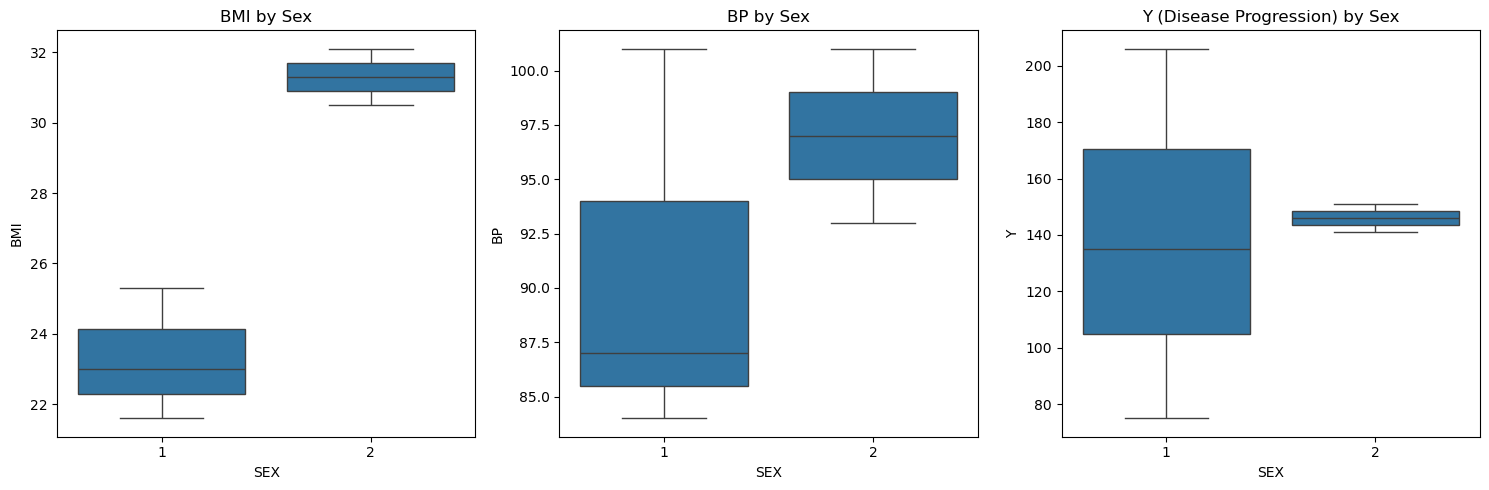

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Größe der Plots anpassen
plt.figure(figsize=(15, 5))

# Boxplot für BMI
plt.subplot(1, 3, 1)
sns.boxplot(x="SEX", y="BMI", data=df)
plt.title("BMI by Sex")

# Boxplot für BP
plt.subplot(1, 3, 2)
sns.boxplot(x="SEX", y="BP", data=df)
plt.title("BP by Sex")

# Boxplot für Y
plt.subplot(1, 3, 3)
sns.boxplot(x="SEX", y="Y", data=df)
plt.title("Y (Disease Progression) by Sex")

plt.tight_layout()
plt.show()

### Task 3: What is the the distribution of Age, Sex, BMI and Y variables?

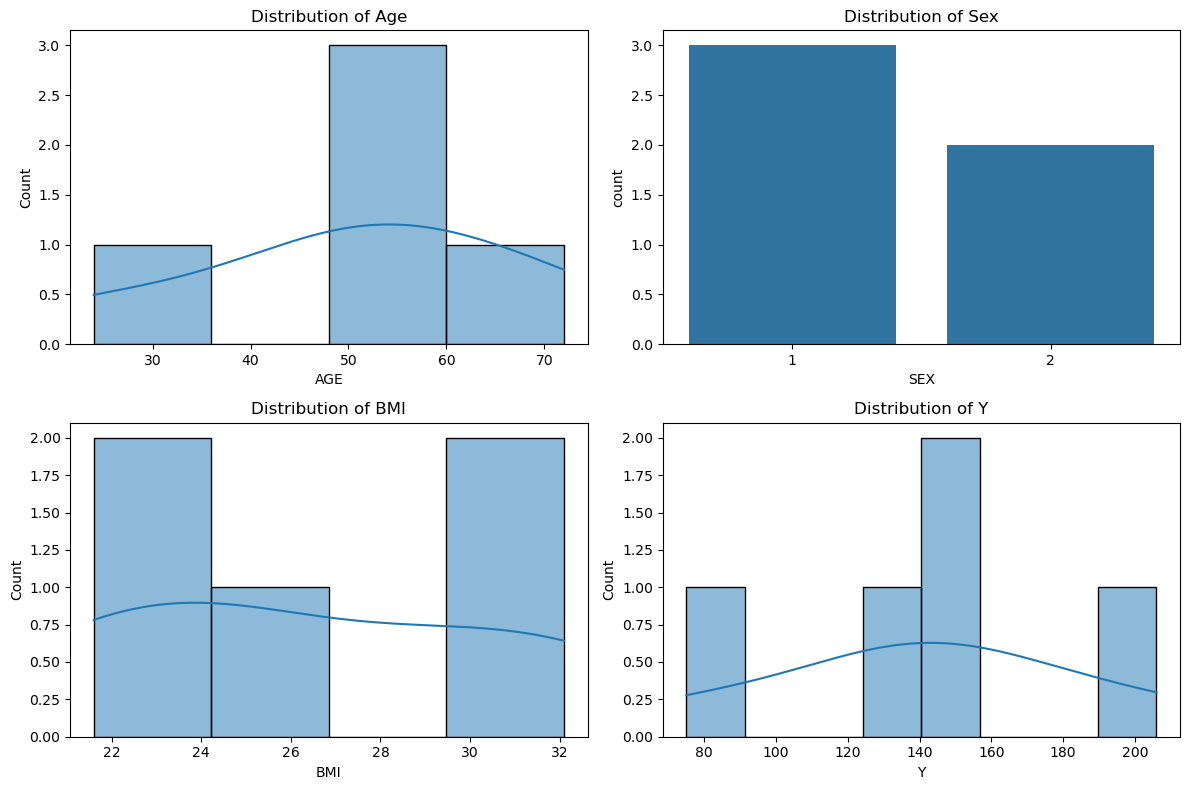

In [17]:
plt.figure(figsize=(12, 8))

# Age
plt.subplot(2, 2, 1)
sns.histplot(df["AGE"], kde=True)
plt.title("Distribution of Age")

# Sex (Barplot)
plt.subplot(2, 2, 2)
sns.countplot(x="SEX", data=df)
plt.title("Distribution of Sex")

# BMI
plt.subplot(2, 2, 3)
sns.histplot(df["BMI"], kde=True)
plt.title("Distribution of BMI")

# Y
plt.subplot(2, 2, 4)
sns.histplot(df["Y"], kde=True)
plt.title("Distribution of Y")

plt.tight_layout()
plt.show()

### Task 4: Test the correlation between different variables and disease progression (Y)

> **Hint** Correlation matrix would give you the most useful information on which values are dependent.

Correlation of each variable with disease progression (Y):
Y      1.000000
S4     0.992242
S6     0.920543
S5     0.885509
S2     0.471520
BMI    0.374450
S1     0.185009
SEX    0.086050
BP    -0.107898
AGE   -0.446528
S3    -0.841188
Name: Y, dtype: float64


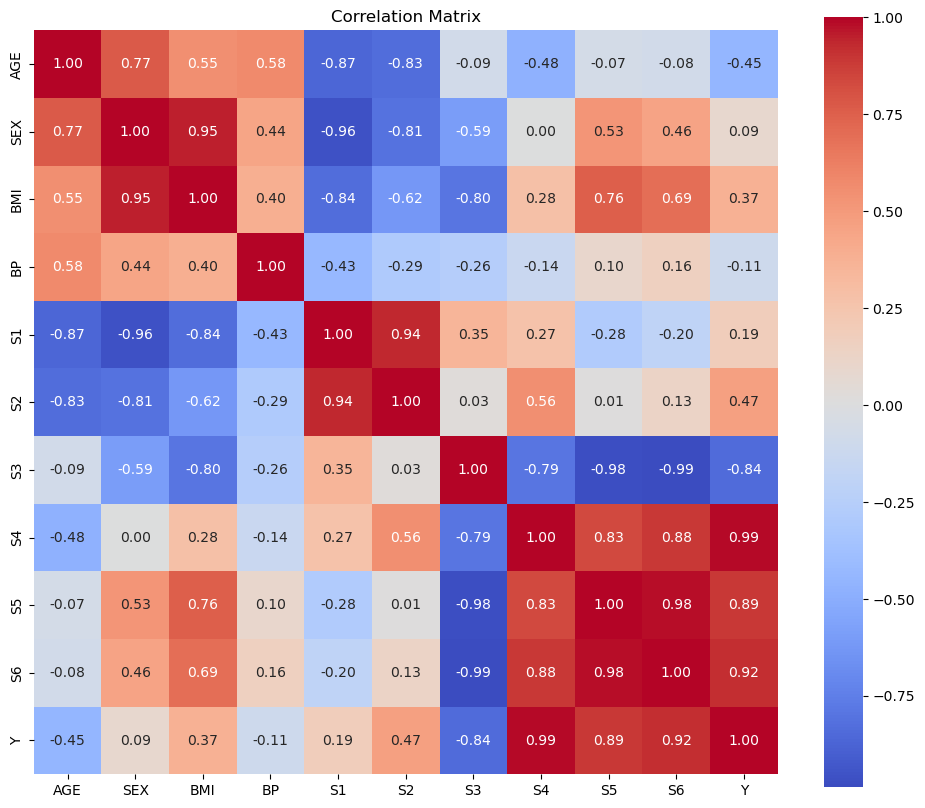

In [18]:
# Korrelationsmatrix berechnen
corr_matrix = df.corr(numeric_only=True)

# Nur Korrelationen mit Y anzeigen (sortiert)
correlation_with_Y = corr_matrix["Y"].sort_values(ascending=False)
print("Correlation of each variable with disease progression (Y):")
print(correlation_with_Y)

# Heatmap der gesamten Korrelationsmatrix anzeigen
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

### Task 5: Test the hypothesis that the degree of diabetes progression is different between men and women

In [20]:
from scipy.stats import ttest_ind

# Daten nach Geschlecht trennen (angenommen: 1 = männlich, 2 = weiblich)
y_male = df[df["SEX"] == 1]["Y"]
y_female = df[df["SEX"] == 2]["Y"]

# T-Test durchführen
t_stat, p_value = ttest_ind(y_male, y_female, equal_var=False)

print(f"T-Statistik: {t_stat:.4f}")
print(f"P-Wert: {p_value:.4f}")

# Ergebnis interpretieren
if p_value < 0.05:
    print("➡️ Unterschied ist statistisch signifikant: Krankheitsverlauf unterscheidet sich zwischen Männern und Frauen.")
else:
    print("➡️ Kein signifikanter Unterschied im Krankheitsverlauf zwischen den Geschlechtern.")


T-Statistik: -0.1920
P-Wert: 0.8649
➡️ Kein signifikanter Unterschied im Krankheitsverlauf zwischen den Geschlechtern.
